In [1]:
import zarr
import s3fs
import numpy as np
from scipy.linalg import solve_banded

S3_BUCKET = "simulations"
STORE_PATH = "flow_export/A1"

fs = s3fs.S3FileSystem(profile='default', client_kwargs={
        'endpoint_url': 'http://localhost:9000'
    })

s3_map = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/data.zarr", s3=fs)
z = zarr.open(
    store=s3_map,
    mode="r",
)

def rmse(X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))
def rel_rmse(X, Y):
    return rmse(X, Y) / np.sqrt(np.mean(Y**2))

In [2]:
z.shape

(1694, 5, 128, 129, 128)

In [3]:
data = z[500:510]

In [4]:
data.shape

(10, 5, 128, 129, 128)

In [5]:
store = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/channel.zarr", s3=fs)
channel_z = zarr.open(
    store=store,
    mode="r",
)
channel = {'x': channel_z['x'][:], 'y': channel_z['y'][:], 'z': channel_z['z'][:]}


In [6]:
y = channel["y"]

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from pathlib import Path

from visualize_ret180 import read_binary_field, read_params, read_y
param = read_params(Path("data/param.txt"))
yp = read_y(Path("data/yp.dat"), param)

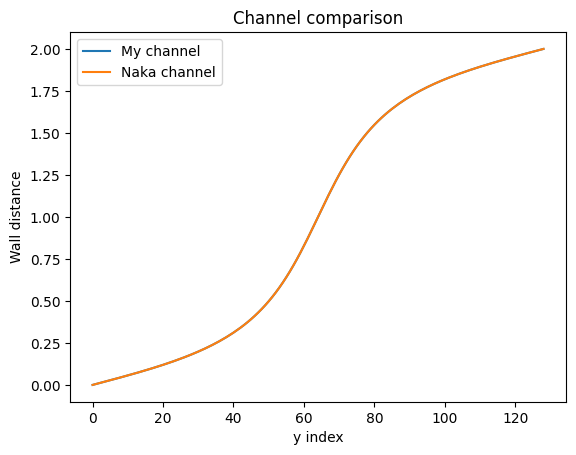

In [8]:
plt.title("Channel comparison")
plt.plot(y, label="My channel")
plt.plot(yp, label="Naka channel")
plt.xlabel("y index")
plt.ylabel("Wall distance")
plt.legend()
plt.show()

In [9]:
rel_rmse(y, yp)

np.float64(1.4552061784316973e-15)

In [10]:
def get_velocity(t):
    ux = read_binary_field(Path(f"data/Ret180/vel/ux{t}"), param)
    uy = read_binary_field(Path(f"data/Ret180/vel/uy{t}"), param)
    uz = read_binary_field(Path(f"data/Ret180/vel/uz{t}"), param)
    return np.stack([ux, uy, uz], axis=-1)

u_naka = np.stack([get_velocity("200"), get_velocity("300")])


In [11]:
u_naka.shape

(2, 256, 129, 128, 3)

In [12]:
data.shape

(10, 5, 128, 129, 128)

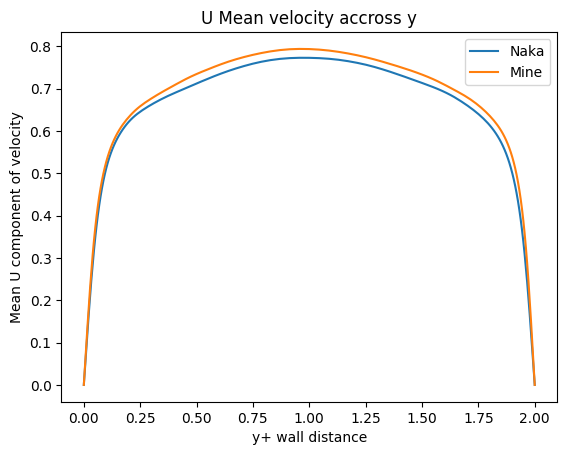

In [13]:
plt.title("U Mean velocity accross y")
plt.plot(yp, u_naka[..., 0].mean((0, 1, 3)), label="Naka")
plt.plot(y, data[:, 0].mean((0, 1, 3)), label="Mine")
plt.ylabel("Mean U component of velocity")
plt.xlabel("y+ wall distance")
plt.legend()
plt.show()

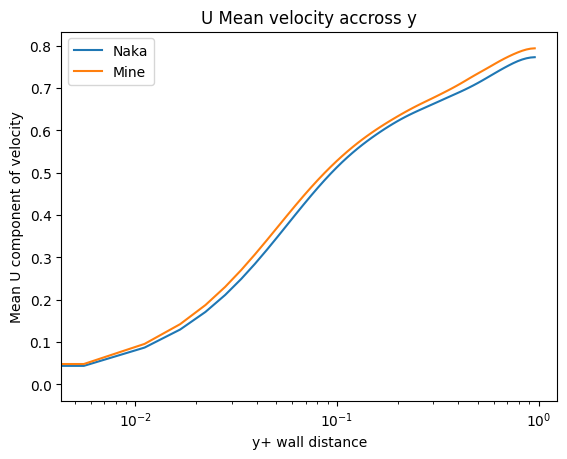

In [14]:
plt.title("U Mean velocity accross y")
plt.plot(yp[:64], u_naka[..., 0].mean((0, 1, 3))[:64], label="Naka")
plt.plot(y[:64], data[:, 0].mean((0, 1, 3))[:64], label="Mine")
plt.ylabel("Mean U component of velocity")
plt.xlabel("y+ wall distance")
plt.xscale("log")
plt.legend()
plt.show()

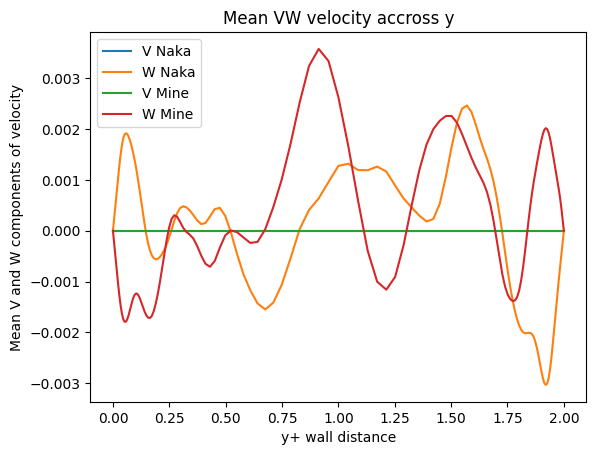

In [15]:
plt.title("Mean VW velocity accross y")
plt.plot(yp, u_naka[..., 1].mean((0, 1, 3)), label="V Naka")
plt.plot(yp, u_naka[..., 2].mean((0, 1, 3)), label="W Naka")
plt.plot(y, data[:, 1].mean((0, 1, 3)), label="V Mine")
plt.plot(y, data[:, 2].mean((0, 1, 3)), label="W Mine")
plt.ylabel("Mean V and W components of velocity")
plt.xlabel("y+ wall distance")
plt.legend()
plt.show()

In [16]:
naka_reordered = np.transpose(u_naka, (0, 4, 1, 2, 3))

In [17]:
def get_grad_func(channel):
    yp = channel['y']
    Lx = channel['x'][-1]
    Nx = channel['x'].shape[0]
    Ly = channel['y'][-1]
    Ny = channel['y'].shape[0]
    Lz = channel['z'][-1]
    Nz = channel['z'].shape[0]
    delta_yp = np.gradient(yp, Ly / (Ny - 1))
    y_stretching = 1.0 / delta_yp 
    
    def broadcast_to(source, target, index):
        d = source.shape
        target_shape = list(target.shape)
        for i in range(len(target_shape)):
            if i != index:
                target_shape[i] = 1
        return source.reshape(tuple(target_shape))
    
    
    def derive_fft(u, direction, h):
        n = u.shape[direction]
        k = 2.0 * np.pi * np.fft.fftfreq(n, d=h)
        k_broad = broadcast_to(k, u, direction)
        u_hat = np.fft.fftn(u, axes=(direction,))
        u_hat_prime = 1.0j * k_broad * u_hat
        return np.fft.ifftn(u_hat_prime, axes=(direction,)).real
        
    def derive_compact(u, direction, h):
        rhs = np.zeros_like(u)
        rhs = np.roll(u, -1, axis=direction) - np.roll(u, 1, axis=direction)
        rhs *= 3.0 / h
        length = u.shape[direction]
        ab = np.zeros((3, length))
        ab[0, 2:] = 1
        ab[1, :] = 4
        ab[2, :-2] = 1
        # BC
        ab[0, 1] = 0
        ab[2, -2] = 0
        rhs_reordered = np.moveaxis(rhs, direction, 0)
        reordered_shape = rhs_reordered.shape
        rhs_reshaped = rhs_reordered.reshape(length, -1)
        u_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
        u_prime = np.moveaxis(u_prime_reshaped.reshape(reordered_shape), 0, direction)
        return u_prime
    
    def grad(field):
        T, C, X, Y, Z = field.shape
        grad = np.zeros((T, C, 3, X, Y, Z))
        grad[:, :, 0, :, :, :] = derive_fft(field, 2, Lx / Nx)
        grad[:, :, 1, :, :, :] = derive_compact(field, 3, Ly / (Ny - 1)) * y_stretching[None, None, None, :, None]
        grad[:, :, 2, :, :, :] = derive_fft(field, 4, Lz / Nz)
        return grad

    return grad

In [18]:
naka_channel = {"x": np.linspace(0, param.Lx, param.Nx), "y": yp, "z": np.linspace(0, param.Lz, param.Nz)}

In [73]:
naka_channel["x"][-1]

np.float64(12.5663706143592)

In [19]:
grad_naka = get_grad_func(naka_channel)

In [20]:
u_grad_naka = grad_naka(naka_reordered)

In [21]:
def get_q(t):
    return read_binary_field(Path(f"data/Ret180/QR/Q{t}"), param)

Q_naka_data = np.stack([get_q("200"), get_q("300")])

In [22]:
Q_naka = -0.5 * np.einsum("tij...,tji...->t...", u_grad_naka, u_grad_naka)

In [23]:
rel_rmse(Q_naka, Q_naka_data)

np.float64(0.004543341556016739)

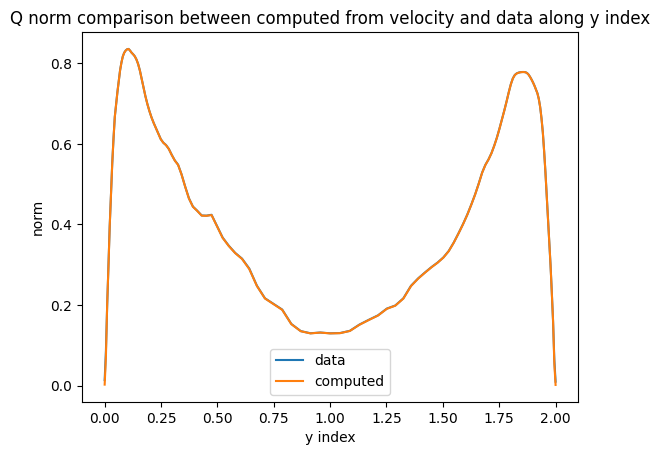

In [74]:
plt.title("Q norm comparison between computed from velocity and data along y index")
plt.plot(y, np.sqrt(np.mean((Q_naka_data) ** 2, axis=(0, 1, 3))), label="data")
plt.plot(y, np.sqrt(np.mean((Q_naka) ** 2, axis=(0, 1, 3))), label="computed")
plt.legend()
plt.xlabel("y index")
plt.ylabel("norm")
plt.show()

In [81]:
u_mean = u_naka[..., 0].mean((1, 3))
Ly = 2.0
Ny = 129
delta_yp = np.gradient(yp, Ly / (Ny - 1))
y_stretching = 1.0 / delta_yp 
du_dy = derive_compact(u_mean, 1, Ly / (Ny - 1)) * y_stretching
wall_grads = np.array([du_dy[:, 0], -du_dy[:, -1]])

In [82]:
wall_grads.mean(1)

array([5.88362245, 5.72308786])

In [83]:
nu = 1/180
u_tau = np.sqrt(nu * wall_grads.mean((0)))
re_t = u_tau / nu

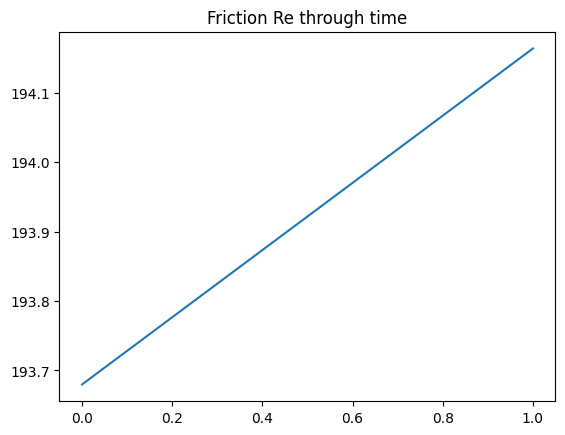

In [87]:
plt.title("Friction Re through time")
plt.plot(re_t)
plt.show()